In [6]:
import pandas as pd
import yfinance as yf
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
stocks = {
    "RELIANCE": "RELIANCE.NS",
    "TCS": "TCS.NS",
    "INFOSYS": "INFY.NS",
    "HDFC_BANK": "HDFCBANK.NS",
    "ICICI_BANK": "ICICIBANK.NS",
    "NIFTY50": "^NSEI"
}

print(stocks)

{'RELIANCE': 'RELIANCE.NS', 'TCS': 'TCS.NS', 'INFOSYS': 'INFY.NS', 'HDFC_BANK': 'HDFCBANK.NS', 'ICICI_BANK': 'ICICIBANK.NS', 'NIFTY50': '^NSEI'}


In [8]:
data = yf.download(
    list(stocks.values()),
    start="2021-01-01",
    end="2026-01-01",
    auto_adjust=False
)

print(data.head())

[*********************100%***********************]  6 of 6 completed

Price        Adj Close                                                     \
Ticker     HDFCBANK.NS ICICIBANK.NS      INFY.NS RELIANCE.NS       TCS.NS   
Date                                                                        
2021-01-01  663.905762   505.926239  1086.097168  897.047119  2521.074219   
2021-01-04  659.689514   509.954437  1110.051758  898.559143  2616.811523   
2021-01-05  664.674377   515.277527  1114.834106  887.388245  2662.915283   
2021-01-06  661.809143   524.340942  1104.752441  863.986023  2627.186279   
2021-01-07  659.806030   518.969971  1087.562134  862.586853  2611.085938   

Price                          Close                                        \
Ticker             ^NSEI HDFCBANK.NS ICICIBANK.NS      INFY.NS RELIANCE.NS   
Date                                                                         
2021-01-01  14018.500000  712.525024   527.500000  1260.449951  917.230957   
2021-01-04  14132.900391  708.000000   531.700012  1288.250000  918.776

In [9]:
os.makedirs("../data/raw", exist_ok=True)

data.to_csv("../data/raw/stock_data_raw.csv")

print("Raw stock data saved successfully!")

Raw stock data saved successfully!


In [10]:
# Keep only the Close prices
close_data = data["Close"]

# Remove rows with missing values
close_data = close_data.dropna()

print("Cleaned data:")
print(close_data.head())

print("\nShape:", close_data.shape)

Cleaned data:
Ticker      HDFCBANK.NS  ICICIBANK.NS      INFY.NS  RELIANCE.NS       TCS.NS  \
Date                                                                           
2021-01-01   712.525024    527.500000  1260.449951   917.230957  2928.250000   
2021-01-04   708.000000    531.700012  1288.250000   918.776978  3039.449951   
2021-01-05   713.349976    537.250000  1293.800049   907.354858  3093.000000   
2021-01-06   710.275024    546.700012  1282.099976   883.426086  3051.500000   
2021-01-07   708.125000    541.099976  1262.150024   881.995422  3032.800049   

Ticker             ^NSEI  
Date                      
2021-01-01  14018.500000  
2021-01-04  14132.900391  
2021-01-05  14199.500000  
2021-01-06  14146.250000  
2021-01-07  14137.349609  

Shape: (1236, 6)


In [11]:
daily_returns = close_data.pct_change()

daily_returns = daily_returns.dropna()

print("Daily returns:")
print(daily_returns.head())

print("\nShape:", daily_returns.shape)

Daily returns:
Ticker      HDFCBANK.NS  ICICIBANK.NS   INFY.NS  RELIANCE.NS    TCS.NS  \
Date                                                                     
2021-01-04    -0.006351      0.007962  0.022056     0.001686  0.037975   
2021-01-05     0.007556      0.010438  0.004308    -0.012432  0.017618   
2021-01-06    -0.004311      0.017590 -0.009043    -0.026372 -0.013417   
2021-01-07    -0.003027     -0.010243 -0.015560    -0.001619 -0.006128   
2021-01-08     0.010874      0.001756  0.039575     0.011799  0.029049   

Ticker         ^NSEI  
Date                  
2021-01-04  0.008161  
2021-01-05  0.004712  
2021-01-06 -0.003750  
2021-01-07 -0.000629  
2021-01-08  0.014847  

Shape: (1235, 6)


In [12]:
volatility = daily_returns.std() * (252 ** 0.5)

print("Annual Volatility:")
print(volatility)

Annual Volatility:
Ticker
HDFCBANK.NS     0.212796
ICICIBANK.NS    0.220774
INFY.NS         0.241407
RELIANCE.NS     0.227315
TCS.NS          0.207875
^NSEI           0.139877
dtype: float64


In [13]:
volatility_df = volatility.reset_index()
volatility_df.columns = ["Asset", "Volatility"]

volatility_df.to_csv("../data/processed/volatility_tableau.csv", index=False)

print(volatility_df)

          Asset  Volatility
0   HDFCBANK.NS    0.212796
1  ICICIBANK.NS    0.220774
2       INFY.NS    0.241407
3   RELIANCE.NS    0.227315
4        TCS.NS    0.207875
5         ^NSEI    0.139877


In [ ]:
cumulative_returns = (1 + daily_returns).cumprod() - 1

print("Cumulative Returns:")
print(cumulative_returns.tail())

Cumulative Returns:
Ticker      HDFCBANK.NS  ICICIBANK.NS   INFY.NS  RELIANCE.NS    TCS.NS  \
Date                                                                     
2025-12-24     0.399530      1.577820  0.319687     0.698809  0.133441   
2025-12-26     0.392372      1.560000  0.313896     0.699899  0.120123   
2025-12-29     0.391811      1.546540  0.304851     0.685072  0.110390   
2025-12-30     0.390688      1.545024  0.286525     0.678748  0.108785   
2025-12-31     0.391109      1.545782  0.281606     0.712110  0.094920   

Ticker         ^NSEI  
Date                  
2025-12-24  0.864829  
2025-12-26  0.857710  
2025-12-29  0.850562  
2025-12-30  0.850330  
2025-12-31  0.863937  


In [ ]:
# Calculate maximum drawdown
running_max = close_data.cummax()

drawdown = (close_data - running_max) / running_max

max_drawdown = drawdown.min()

print("Maximum Drawdown:")
print(max_drawdown)

Maximum Drawdown:
Ticker
HDFCBANK.NS    -0.241251
ICICIBANK.NS   -0.223298
INFY.NS        -0.369219
RELIANCE.NS    -0.274221
TCS.NS         -0.365710
^NSEI          -0.172298
dtype: float64


In [15]:
correlation = daily_returns.corr()

print("Correlation Matrix:")
print(correlation)

Correlation Matrix:
Ticker        HDFCBANK.NS  ICICIBANK.NS   INFY.NS  RELIANCE.NS    TCS.NS  \
Ticker                                                                     
HDFCBANK.NS      1.000000      0.531632  0.258390     0.363448  0.229695   
ICICIBANK.NS     0.531632      1.000000  0.264989     0.367184  0.218879   
INFY.NS          0.258390      0.264989  1.000000     0.273463  0.702128   
RELIANCE.NS      0.363448      0.367184  0.273463     1.000000  0.291582   
TCS.NS           0.229695      0.218879  0.702128     0.291582  1.000000   
^NSEI            0.694474      0.685710  0.554908     0.689967  0.528785   

Ticker           ^NSEI  
Ticker                  
HDFCBANK.NS   0.694474  
ICICIBANK.NS  0.685710  
INFY.NS       0.554908  
RELIANCE.NS   0.689967  
TCS.NS        0.528785  
^NSEI         1.000000  


In [17]:
correlation_tableau = correlation.copy()

correlation_tableau.index.name = "Asset 1"
correlation_tableau.columns.name = "Asset 2"

correlation_tableau = correlation_tableau.reset_index()

correlation_tableau = correlation_tableau.melt(
    id_vars="Asset 1",
    var_name="Asset 2",
    value_name="Correlation"
)

correlation_tableau.to_csv(
    "../data/processed/correlation_tableau.csv",
    index=False
)

print(correlation_tableau)

         Asset 1       Asset 2  Correlation
0    HDFCBANK.NS   HDFCBANK.NS     1.000000
1   ICICIBANK.NS   HDFCBANK.NS     0.531632
2        INFY.NS   HDFCBANK.NS     0.258390
3    RELIANCE.NS   HDFCBANK.NS     0.363448
4         TCS.NS   HDFCBANK.NS     0.229695
5          ^NSEI   HDFCBANK.NS     0.694474
6    HDFCBANK.NS  ICICIBANK.NS     0.531632
7   ICICIBANK.NS  ICICIBANK.NS     1.000000
8        INFY.NS  ICICIBANK.NS     0.264989
9    RELIANCE.NS  ICICIBANK.NS     0.367184
10        TCS.NS  ICICIBANK.NS     0.218879
11         ^NSEI  ICICIBANK.NS     0.685710
12   HDFCBANK.NS       INFY.NS     0.258390
13  ICICIBANK.NS       INFY.NS     0.264989
14       INFY.NS       INFY.NS     1.000000
15   RELIANCE.NS       INFY.NS     0.273463
16        TCS.NS       INFY.NS     0.702128
17         ^NSEI       INFY.NS     0.554908
18   HDFCBANK.NS   RELIANCE.NS     0.363448
19  ICICIBANK.NS   RELIANCE.NS     0.367184
20       INFY.NS   RELIANCE.NS     0.273463
21   RELIANCE.NS   RELIANCE.NS  

In [19]:
weekly_returns = close_data.resample("W").last().pct_change().dropna()

monthly_returns = close_data.resample("ME").last().pct_change().dropna()

print(monthly_returns.head())

Ticker      HDFCBANK.NS  ICICIBANK.NS   INFY.NS  RELIANCE.NS    TCS.NS  \
Date                                                                     
2021-02-28     0.103488      0.113128  0.011501     0.132387 -0.069761   
2021-03-31    -0.026558     -0.026182  0.091558    -0.039649  0.097968   
2021-04-30    -0.054464      0.031610 -0.010014    -0.004293 -0.044747   
2021-05-31     0.073320      0.103664  0.029091     0.083129  0.040683   
2021-06-30    -0.011842     -0.048057  0.134206    -0.022983  0.059067   

Ticker         ^NSEI  
Date                  
2021-02-28  0.065609  
2021-03-31  0.011119  
2021-04-30 -0.004057  
2021-05-31  0.065046  
2021-06-30  0.008901  


In [20]:
monthly_tableau = monthly_returns.copy()

monthly_tableau.index.name = "Date"

monthly_tableau = monthly_tableau.reset_index()

monthly_tableau = monthly_tableau.melt(
    id_vars="Date",
    var_name="Asset",
    value_name="Monthly Return"
)

monthly_tableau.to_csv(
    "../data/processed/monthly_returns_tableau.csv",
    index=False
)

print(monthly_tableau.head())

        Date        Asset  Monthly Return
0 2021-02-28  HDFCBANK.NS        0.103488
1 2021-03-31  HDFCBANK.NS       -0.026558
2 2021-04-30  HDFCBANK.NS       -0.054464
3 2021-05-31  HDFCBANK.NS        0.073320
4 2021-06-30  HDFCBANK.NS       -0.011842


In [22]:
# Calculate average annual return
annual_return = daily_returns.mean() * 252

# Create Risk vs Return table
risk_return = pd.DataFrame({
    "Annual Return": annual_return,
    "Annual Volatility": volatility
})

print("Risk vs Return:")
print(risk_return)

Risk vs Return:
              Annual Return  Annual Volatility
Ticker                                        
HDFCBANK.NS        0.089984           0.212796
ICICIBANK.NS       0.214920           0.220774
INFY.NS            0.079799           0.241407
RELIANCE.NS        0.135522           0.227315
TCS.NS             0.040071           0.207875
^NSEI              0.136884           0.139877


In [24]:
risk_return_tableau = risk_return.reset_index()

risk_return_tableau.columns = [
    "Asset",
    "Annual Return",
    "Annual Volatility"
]

risk_return_tableau.to_csv(
    "../data/processed/risk_return_tableau.csv",
    index=False
)

print(risk_return_tableau)

          Asset  Annual Return  Annual Volatility
0   HDFCBANK.NS       0.089984           0.212796
1  ICICIBANK.NS       0.214920           0.220774
2       INFY.NS       0.079799           0.241407
3   RELIANCE.NS       0.135522           0.227315
4        TCS.NS       0.040071           0.207875
5         ^NSEI       0.136884           0.139877


In [26]:
daily_returns_tableau = daily_returns.copy()

daily_returns_tableau.index.name = "Date"

daily_returns_tableau = daily_returns_tableau.reset_index()

daily_returns_tableau = daily_returns_tableau.melt(
    id_vars="Date",
    var_name="Asset",
    value_name="Daily Return"
)

daily_returns_tableau.to_csv(
    "../data/processed/daily_returns_tableau.csv",
    index=False
)

print(daily_returns_tableau.head())

        Date        Asset  Daily Return
0 2021-01-04  HDFCBANK.NS     -0.006351
1 2021-01-05  HDFCBANK.NS      0.007556
2 2021-01-06  HDFCBANK.NS     -0.004311
3 2021-01-07  HDFCBANK.NS     -0.003027
4 2021-01-08  HDFCBANK.NS      0.010874


In [25]:
# Save cleaned closing-price data
close_data.to_csv("../data/processed/cleaned_close_prices.csv")

print("Cleaned data saved successfully!")

Cleaned data saved successfully!


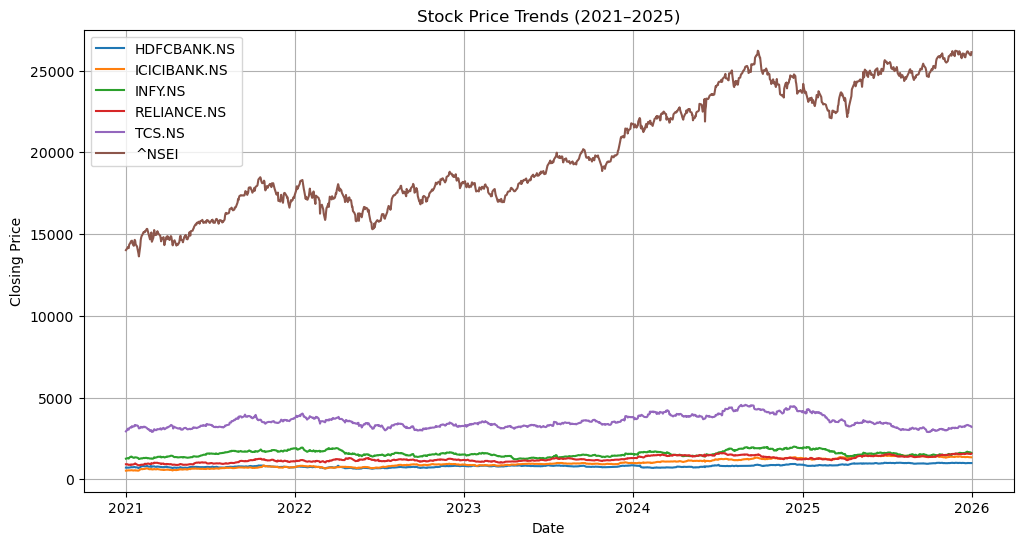

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for column in close_data.columns:
    plt.plot(close_data.index, close_data[column], label=column)

plt.title("Stock Price Trends (2021–2025)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

plt.show()

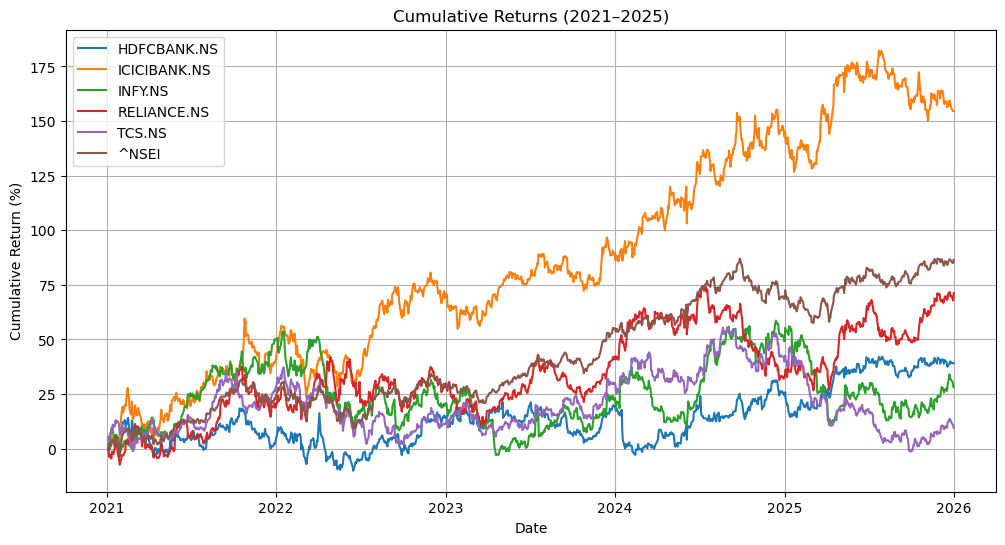

In [ ]:
plt.figure(figsize=(12, 6))

for column in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[column] * 100, label=column)

plt.title("Cumulative Returns (2021–2025)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")
plt.legend()
plt.grid(True)

plt.show()

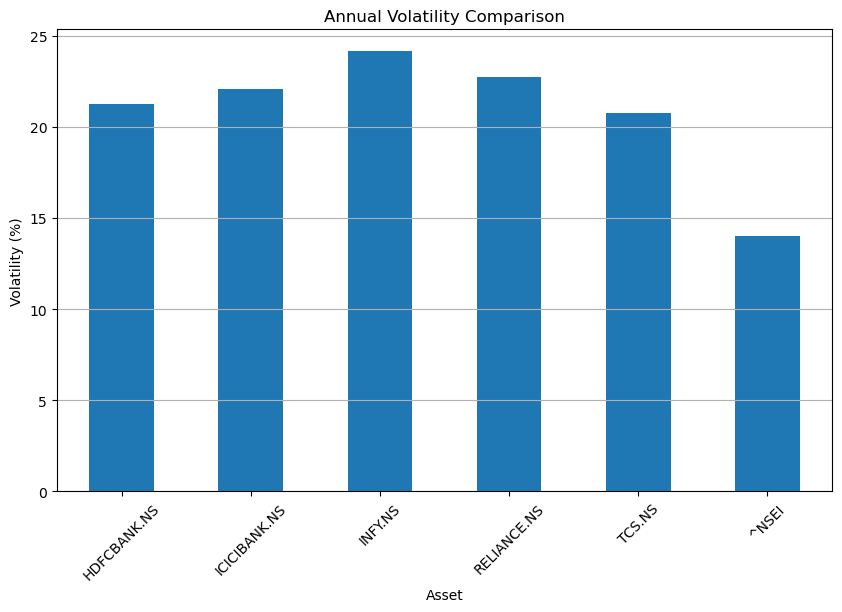

In [ ]:
plt.figure(figsize=(10, 6))

volatility_percent = volatility * 100

volatility_percent.plot(kind="bar")

plt.title("Annual Volatility Comparison")
plt.xlabel("Asset")
plt.ylabel("Volatility (%)")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

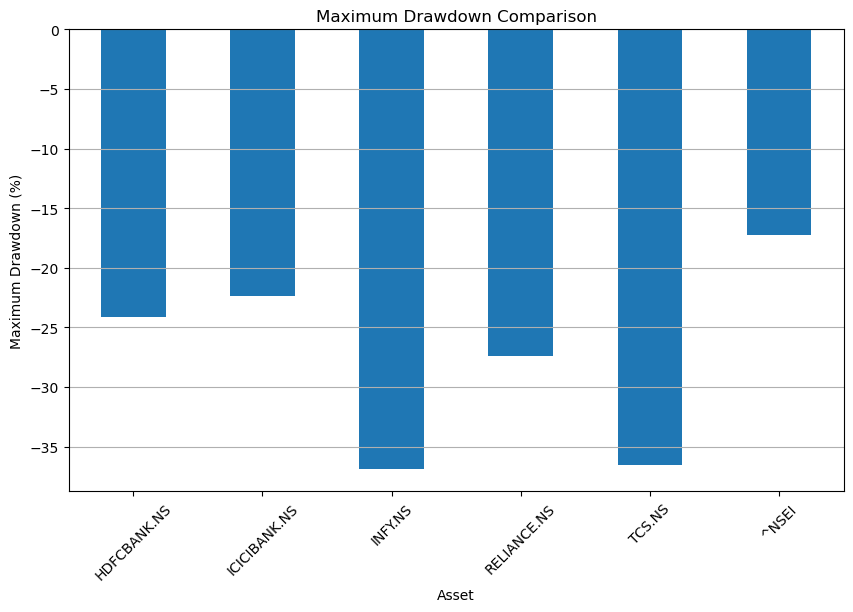

In [ ]:
plt.figure(figsize=(10, 6))

max_drawdown_percent = max_drawdown * 100

max_drawdown_percent.plot(kind="bar")

plt.title("Maximum Drawdown Comparison")
plt.xlabel("Asset")
plt.ylabel("Maximum Drawdown (%)")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

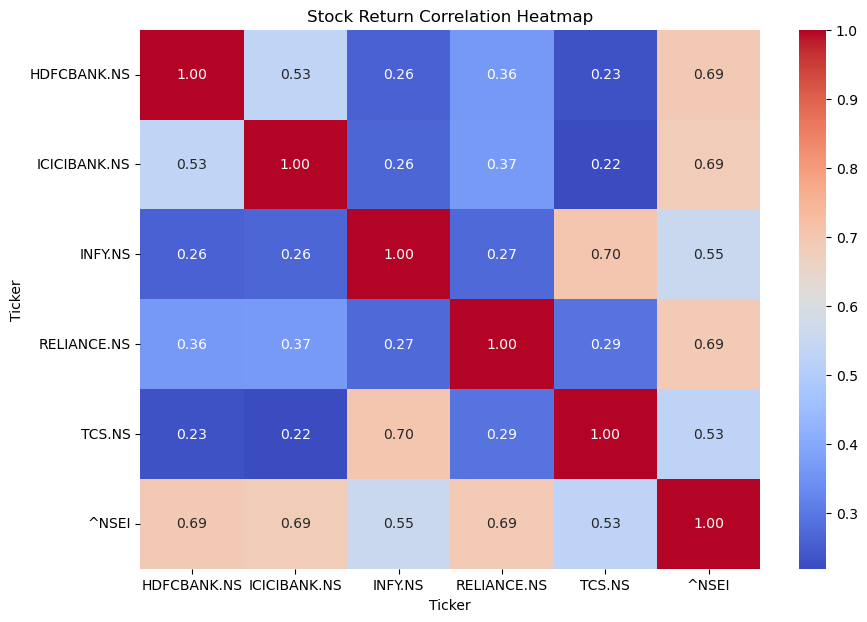

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Stock Return Correlation Heatmap")
plt.show()

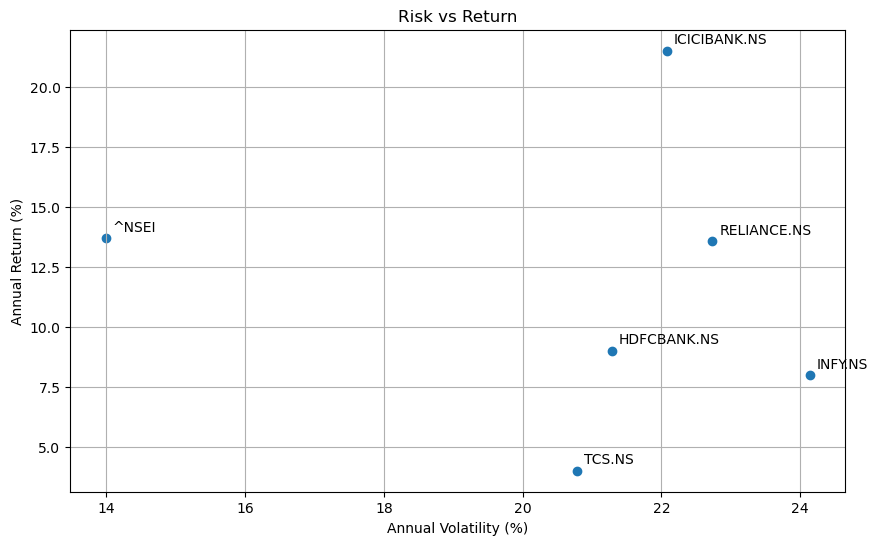

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    risk_return["Annual Volatility"] * 100,
    risk_return["Annual Return"] * 100
)

for asset in risk_return.index:
    plt.annotate(
        asset,
        (
            risk_return.loc[asset, "Annual Volatility"] * 100,
            risk_return.loc[asset, "Annual Return"] * 100
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Risk vs Return")
plt.xlabel("Annual Volatility (%)")
plt.ylabel("Annual Return (%)")
plt.grid(True)

plt.show()

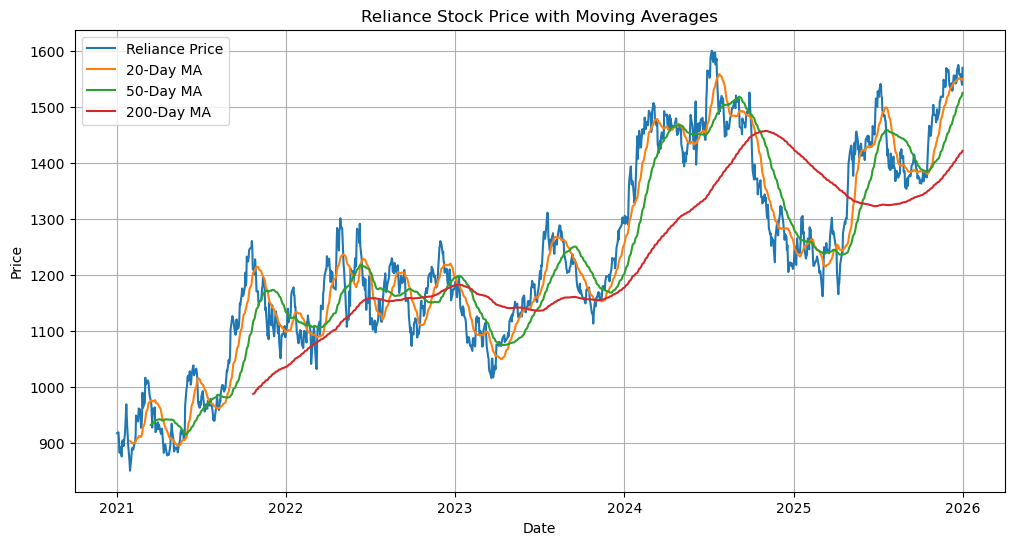

In [ ]:
# Calculate moving averages for Reliance
stock = close_data["RELIANCE.NS"]

ma20 = stock.rolling(20).mean()
ma50 = stock.rolling(50).mean()
ma200 = stock.rolling(200).mean()

plt.figure(figsize=(12, 6))

plt.plot(stock, label="Reliance Price")
plt.plot(ma20, label="20-Day MA")
plt.plot(ma50, label="50-Day MA")
plt.plot(ma200, label="200-Day MA")

plt.title("Reliance Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Weekly returns
weekly_returns = close_data.resample("W").last().pct_change().dropna()

# Monthly returns
monthly_returns = close_data.resample("ME").last().pct_change().dropna()

print("Weekly Returns:")
print(weekly_returns.head())

print("\nMonthly Returns:")
print(monthly_returns.head())

Weekly Returns:
Ticker      HDFCBANK.NS  ICICIBANK.NS   INFY.NS  RELIANCE.NS    TCS.NS  \
Date                                                                     
2021-01-10     0.004631      0.027583  0.040977    -0.027069  0.065790   
2021-01-17     0.024447      0.001753  0.025036     0.001939  0.036031   
2021-01-24    -0.015750     -0.016943 -0.003048     0.057885  0.021572   
2021-01-31    -0.036750      0.005995 -0.075922    -0.101312 -0.058052   
2021-02-07     0.148939      0.143669  0.026674     0.044409  0.014977   

Ticker         ^NSEI  
Date                  
2021-01-10  0.023451  
2021-01-17  0.006026  
2021-01-24 -0.004282  
2021-01-31 -0.051302  
2021-02-07  0.094587  

Monthly Returns:
Ticker      HDFCBANK.NS  ICICIBANK.NS   INFY.NS  RELIANCE.NS    TCS.NS  \
Date                                                                     
2021-02-28     0.103488      0.113128  0.011501     0.132387 -0.069761   
2021-03-31    -0.026558     -0.026182  0.091558    -0.039649  0.

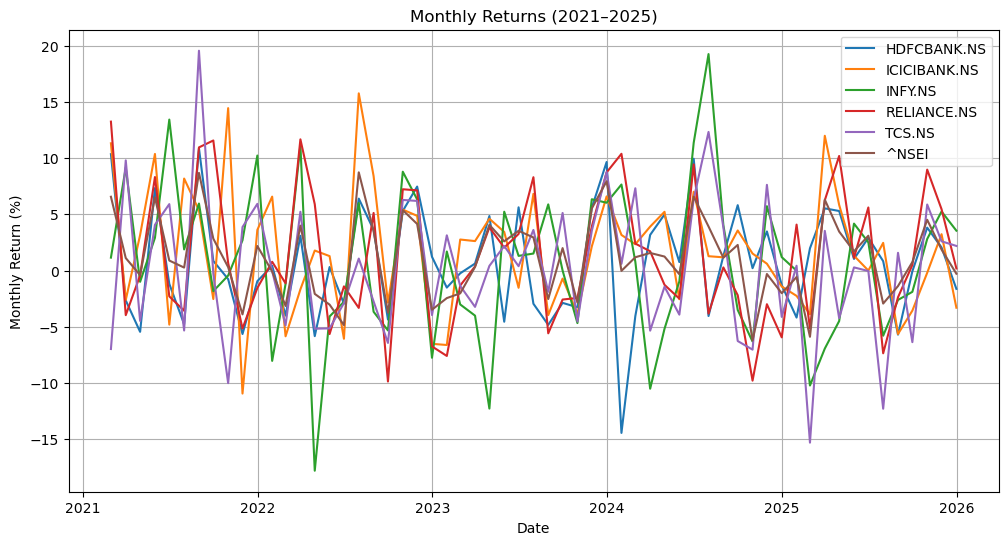

In [ ]:
plt.figure(figsize=(12, 6))

for column in monthly_returns.columns:
    plt.plot(
        monthly_returns.index,
        monthly_returns[column] * 100,
        label=column
    )

plt.title("Monthly Returns (2021–2025)")
plt.xlabel("Date")
plt.ylabel("Monthly Return (%)")
plt.legend()
plt.grid(True)

plt.show()

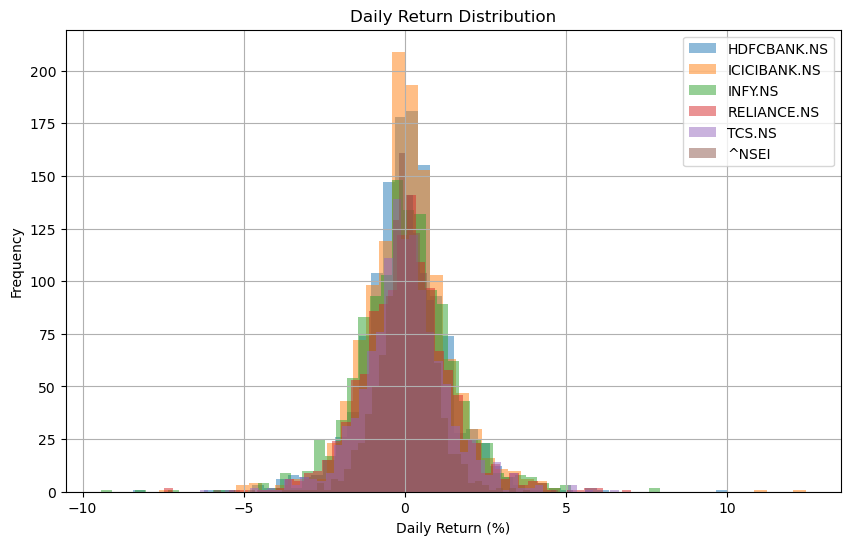

In [ ]:
plt.figure(figsize=(10, 6))

for column in daily_returns.columns:
    plt.hist(
        daily_returns[column] * 100,
        bins=50,
        alpha=0.5,
        label=column
    )

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Calculate Sharpe Ratio
sharpe_ratio = (
    daily_returns.mean() / daily_returns.std()
) * (252 ** 0.5)

print("Sharpe Ratio:")
print(sharpe_ratio)

Sharpe Ratio:
Ticker
HDFCBANK.NS     0.422865
ICICIBANK.NS    0.973485
INFY.NS         0.330559
RELIANCE.NS     0.596187
TCS.NS          0.192763
^NSEI           0.978601
dtype: float64


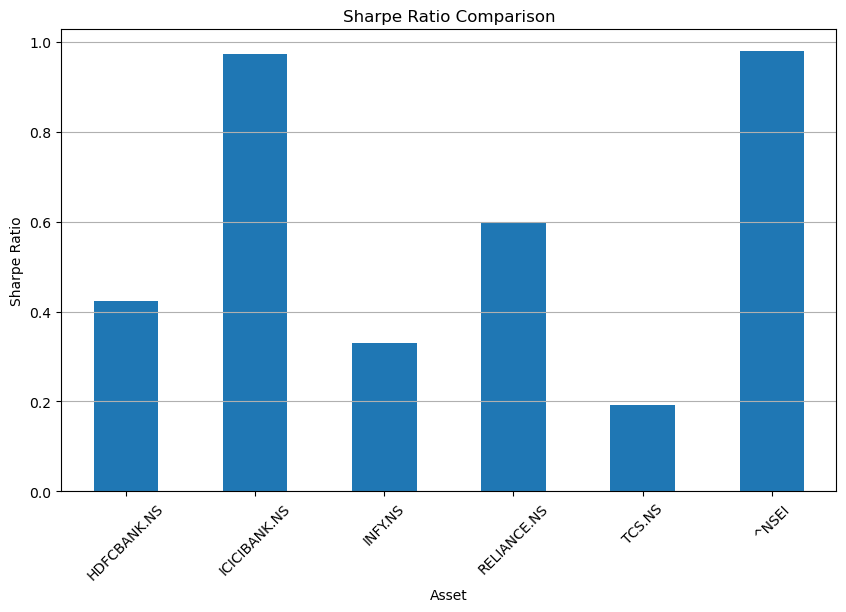

In [ ]:
plt.figure(figsize=(10, 6))

sharpe_ratio.plot(kind="bar")

plt.title("Sharpe Ratio Comparison")
plt.xlabel("Asset")
plt.ylabel("Sharpe Ratio")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [ ]:
# Save analysis results

risk_return.to_csv("../data/processed/risk_return.csv")
volatility.to_csv("../data/processed/volatility.csv")
max_drawdown.to_csv("../data/processed/max_drawdown.csv")
sharpe_ratio.to_csv("../data/processed/sharpe_ratio.csv")
correlation.to_csv("../data/processed/correlation_matrix.csv")
monthly_returns.to_csv("../data/processed/monthly_returns.csv")

print("All analysis data saved successfully!")

All analysis data saved successfully!


In [ ]:
# Create final dashboard dataset

dashboard_data = close_data.copy()

dashboard_data["NIFTY50"] = close_data["^NSEI"]

dashboard_data.to_csv(
    "../data/processed/dashboard_data.csv"
)

print("Dashboard dataset created successfully!")
print(dashboard_data.head())

Dashboard dataset created successfully!
Ticker      HDFCBANK.NS  ICICIBANK.NS      INFY.NS  RELIANCE.NS       TCS.NS  \
Date                                                                           
2021-01-01   712.525024    527.500000  1260.449951   917.230957  2928.250000   
2021-01-04   708.000000    531.700012  1288.250000   918.776978  3039.449951   
2021-01-05   713.349976    537.250000  1293.800049   907.354858  3093.000000   
2021-01-06   710.275024    546.700012  1282.099976   883.426086  3051.500000   
2021-01-07   708.125000    541.099976  1262.150024   881.995422  3032.800049   

Ticker             ^NSEI       NIFTY50  
Date                                    
2021-01-01  14018.500000  14018.500000  
2021-01-04  14132.900391  14132.900391  
2021-01-05  14199.500000  14199.500000  
2021-01-06  14146.250000  14146.250000  
2021-01-07  14137.349609  14137.349609  
